# Import necessary libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset

In [ ]:
df = pd.read_csv("Housing_Prices_India.csv")
# Top 5 rows of the dataset
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,38684,Haryana,Gurgaon,Locality_123,Independent House,4,692,256.62,0.37,2022,...,3,6,6,Medium,Yes,No,"Playground, Pool",South,Builder,Ready_to_Move
1,64940,Andhra Pradesh,Vishakhapatnam,Locality_74,Apartment,2,3094,86.04,0.03,2015,...,10,3,8,Medium,No,No,"Gym, Clubhouse, Pool, Garden",South,Builder,Under_Construction
2,3955,Madhya Pradesh,Bhopal,Locality_486,Apartment,3,4993,237.86,0.05,1995,...,30,10,1,High,No,No,"Gym, Pool, Playground, Clubhouse, Garden",West,Owner,Ready_to_Move
3,120375,Punjab,Ludhiana,Locality_13,Villa,1,2461,339.41,0.14,2018,...,7,10,5,Low,Yes,No,"Pool, Gym",South,Owner,Under_Construction
4,172862,Haryana,Faridabad,Locality_22,Independent House,2,4535,124.99,0.03,1991,...,34,5,9,Medium,No,Yes,Pool,South,Builder,Under_Construction


# Initial Inspection

In [ ]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              10000 non-null  int64  
 1   State                           10000 non-null  object 
 2   City                            10000 non-null  object 
 3   Locality                        10000 non-null  object 
 4   Property_Type                   10000 non-null  object 
 5   BHK                             10000 non-null  int64  
 6   Size_in_SqFt                    10000 non-null  int64  
 7   Price_in_Lakhs                  10000 non-null  float64
 8   Price_per_SqFt                  10000 non-null  float64
 9   Year_Built                      10000 non-null  int64  
 10  Furnished_Status                10000 non-null  object 
 11  Floor_No                        10000 non-null  int64  
 12  Total_Floor

In [63]:
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64


In [64]:
df.shape

(10000, 23)

# Exploratory Data Analysis (EDA)

In [65]:
state_price = df.groupby('State')['Price_in_Lakhs'].agg(['mean', 'median', 'min', 'max', 'std']).reset_index()
print(state_price)

             State        mean   median    min     max         std
0   Andhra Pradesh  256.172828  256.420  11.41  499.93  141.097925
1            Assam  259.791748  256.295  10.87  499.73  138.501775
2            Bihar  258.253661  260.090  11.22  499.36  141.207183
3     Chhattisgarh  255.184339  252.440  11.94  499.80  142.578586
4            Delhi  238.595767  225.870  10.32  499.23  142.200558
5          Gujarat  255.474807  253.820  11.30  499.93  140.904261
6          Haryana  253.386933  259.945  11.94  496.96  137.260320
7        Jharkhand  245.973095  246.435  12.15  499.30  142.261864
8        Karnataka  257.351276  258.015  11.27  499.20  143.184112
9           Kerala  243.916250  240.115  10.49  496.12  142.276150
10  Madhya Pradesh  261.592104  256.370  10.31  497.95  140.220513
11     Maharashtra  246.518772  232.250  10.87  498.56  139.351777
12          Odisha  249.859735  268.890  10.03  498.16  137.702385
13          Punjab  248.663569  235.295  11.05  499.56  143.83

<ipython-input-66-227fdc7f43ed>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='State', palette='Set1')


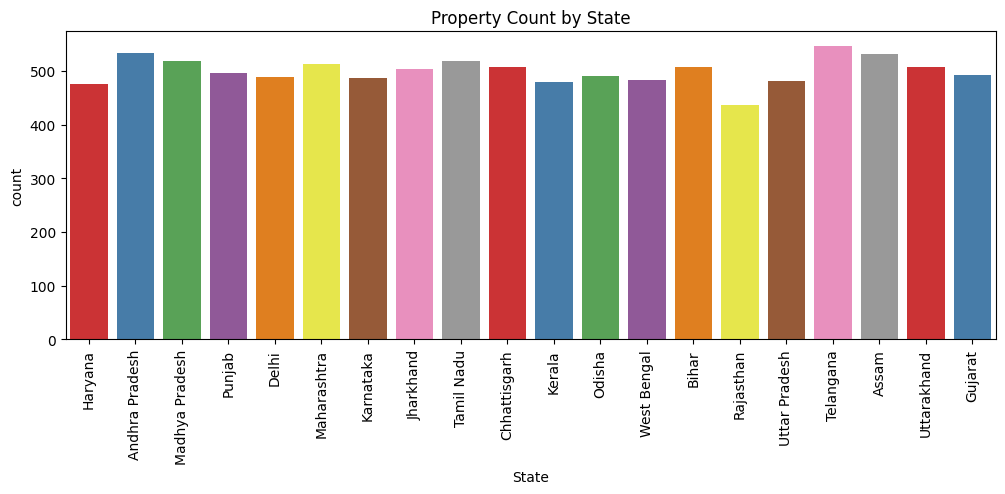

<ipython-input-66-227fdc7f43ed>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='City', palette='Set2')


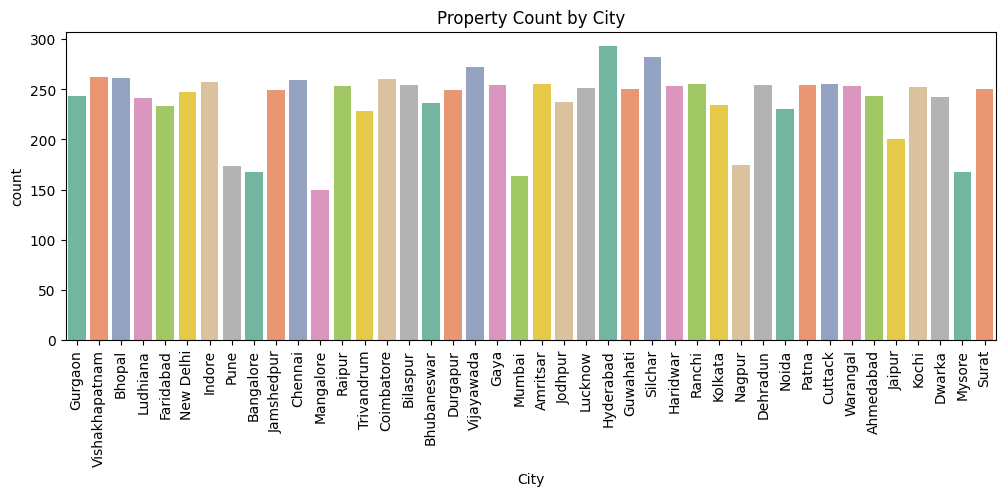

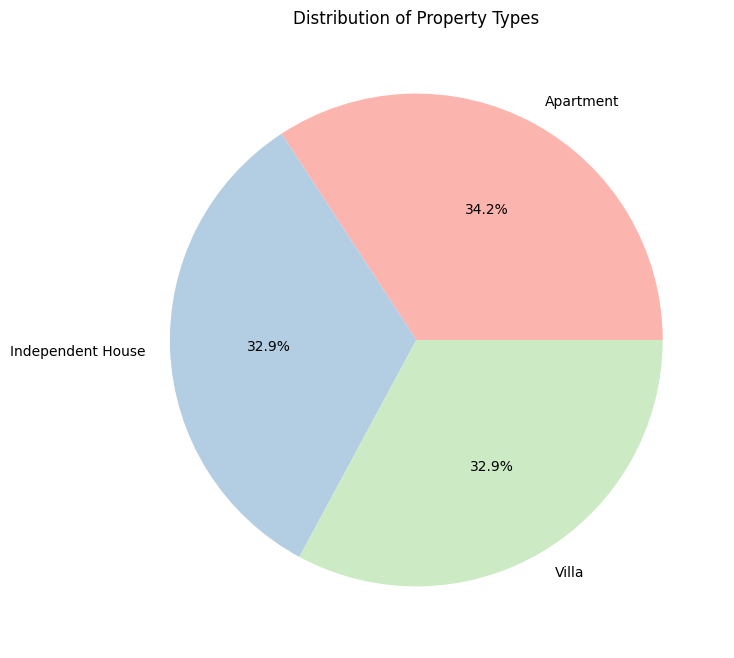

In [66]:
# Count of properties by State
plt.figure(figsize=(12, 4))
sns.countplot(data=df, x='State', palette='Set1')
plt.title('Property Count by State')
plt.xticks(rotation=90)
plt.show()

# Count of properties by City
plt.figure(figsize=(12, 4))
sns.countplot(data=df, x='City', palette='Set2')
plt.title('Property Count by City')
plt.xticks(rotation=90)
plt.show()

property_type_count = df['Property_Type'].value_counts()
# Plotting the pie chart
plt.figure(figsize=(3, 3))
property_type_count.plot.pie(autopct='%1.1f%%', colors=sns.color_palette('Pastel1', len(property_type_count)),
                             figsize=(10, 8), legend=False)
plt.title('Distribution of Property Types')
plt.ylabel('')  # Hide the y-axis label
plt.show()


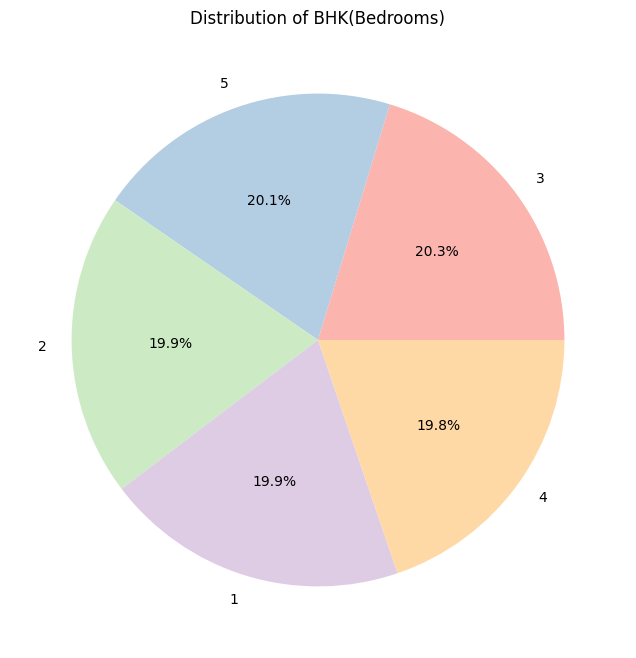

In [67]:
bhk_count = df['BHK'].value_counts()
# Plotting the pie chart
plt.figure(figsize=(3, 3))
bhk_count.plot.pie(autopct='%1.1f%%', colors=sns.color_palette('Pastel1', len(bhk_count)),
                             figsize=(10, 8), legend=False)
plt.title('Distribution of BHK(Bedrooms)')
plt.ylabel('')  # Hide the y-axis label
plt.show()


<ipython-input-68-2e80d38ba766>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.groupby('State')['Price_per_SqFt'].mean().reset_index(), x='State', y='Price_per_SqFt', palette='coolwarm')


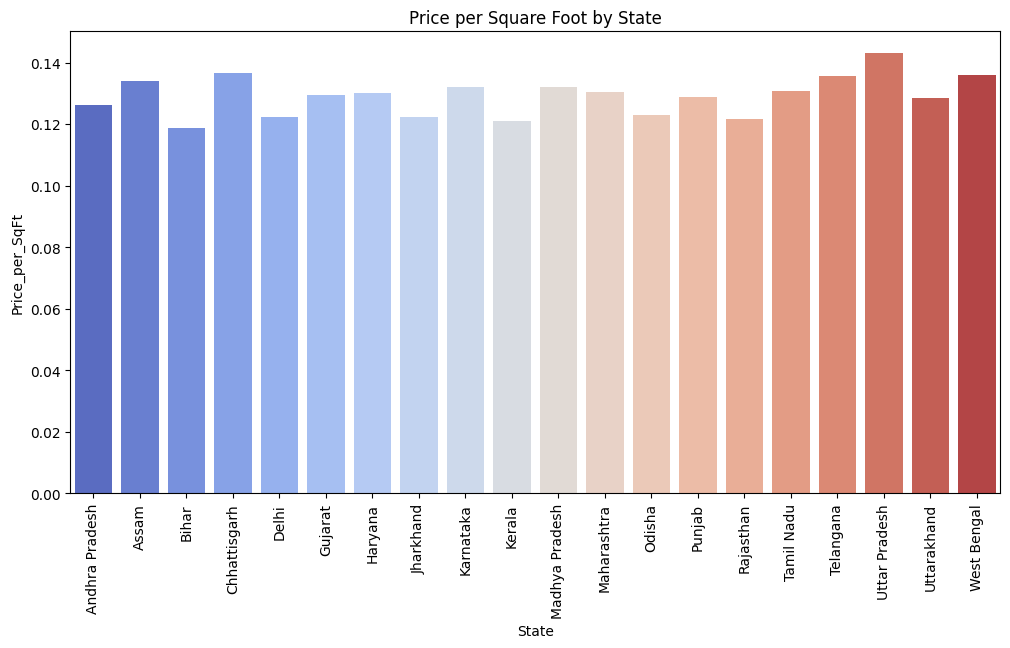

In [68]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df.groupby('State')['Price_per_SqFt'].mean().reset_index(), x='State', y='Price_per_SqFt', palette='coolwarm')
plt.title('Price per Square Foot by State')
plt.xticks(rotation=90)
plt.show()

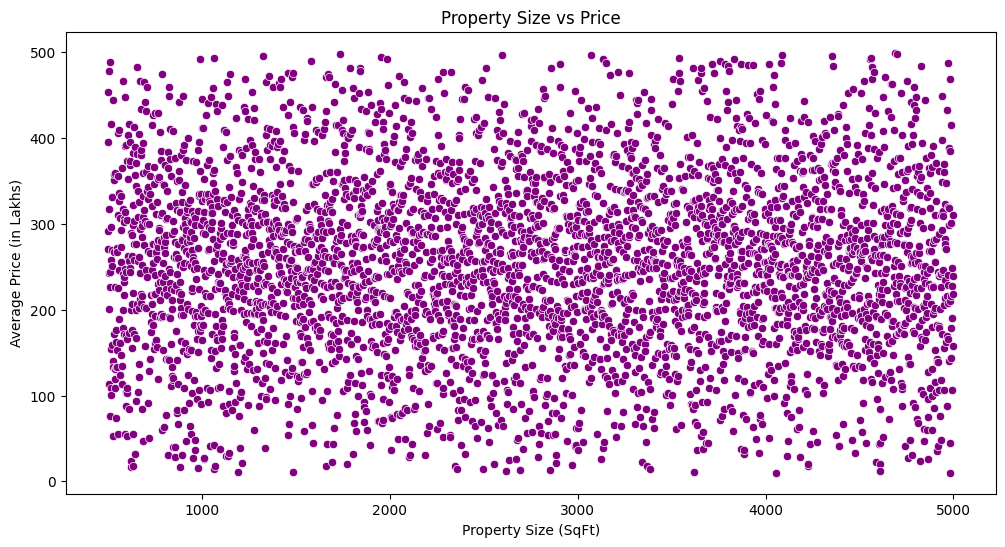

In [69]:
size_price_group_exact = df.groupby('Size_in_SqFt').agg({
    'Price_in_Lakhs': 'mean',  # Average price for each exact size
}).reset_index()

# Plotting
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Size_in_SqFt', y='Price_in_Lakhs', data=size_price_group_exact, color='purple')
plt.title('Property Size vs Price')
plt.xlabel('Property Size (SqFt)')
plt.ylabel('Average Price (in Lakhs)')
plt.show()


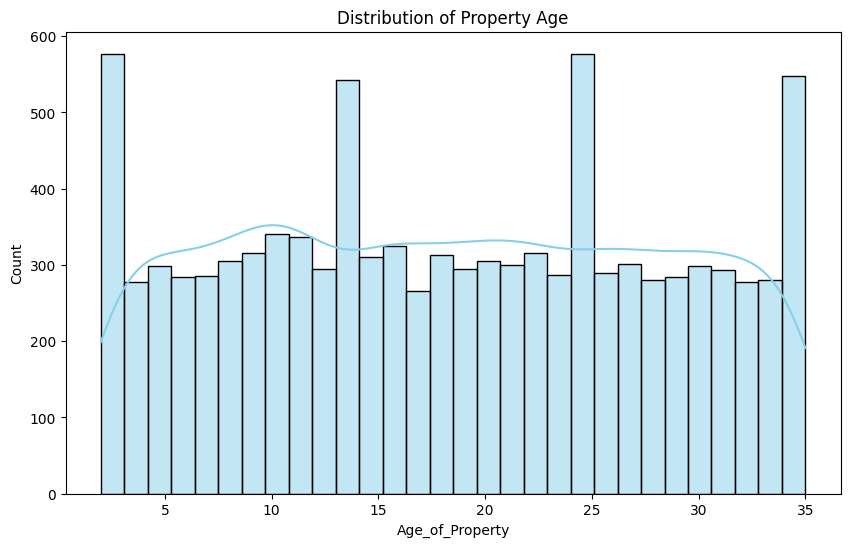

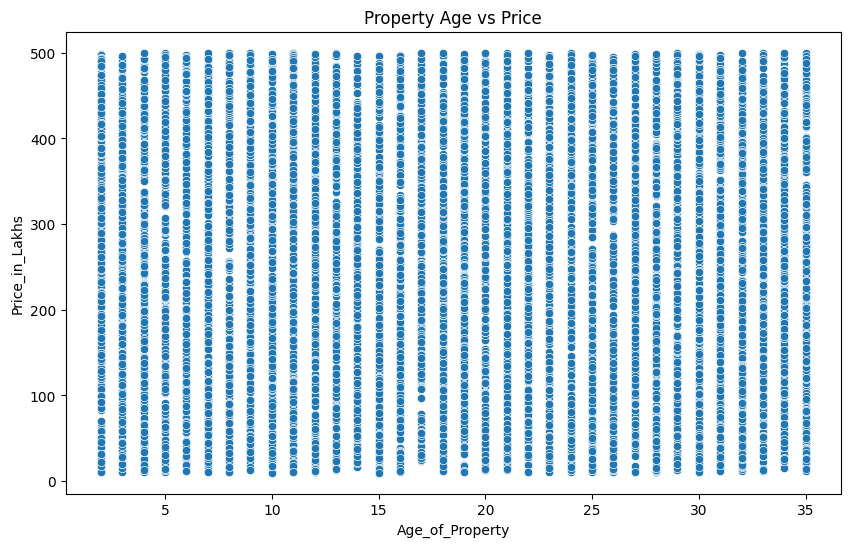

In [70]:
# Property age distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Age_of_Property'], kde=True, color='skyblue', bins=30)
plt.title('Distribution of Property Age')
plt.show()

# Property Age vs Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age_of_Property', y='Price_in_Lakhs', data=df)
plt.title('Property Age vs Price')
plt.show()

<ipython-input-71-61aa47ea01a4>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=amenity_counts.head(15).index, y=amenity_counts.head(15).values, palette='viridis')


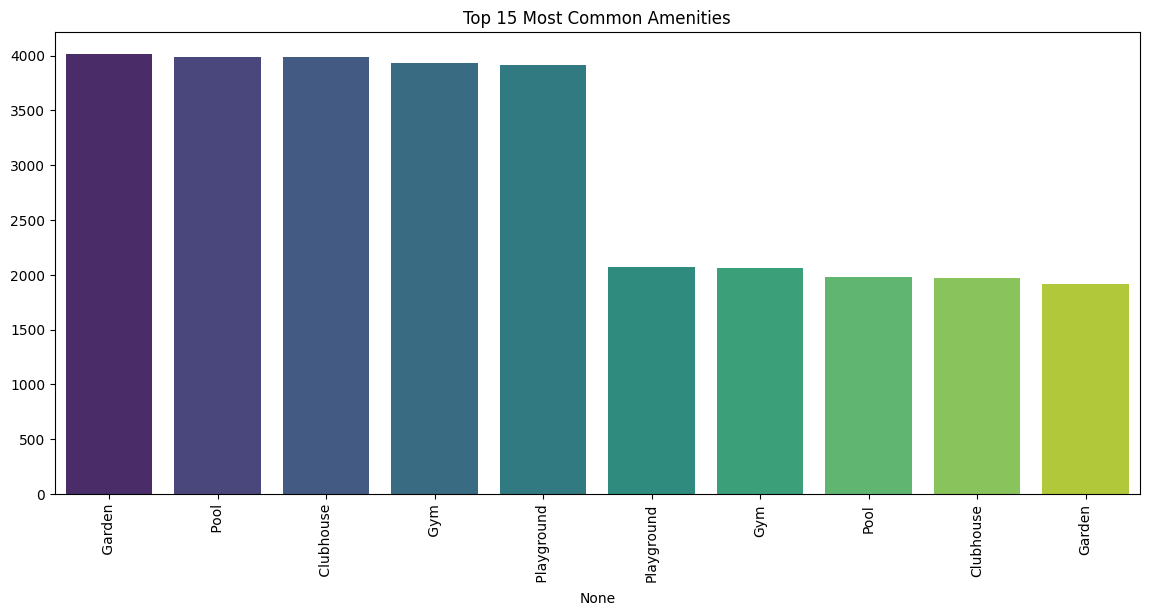

In [71]:
# Top amenities
df['Amenities'] = df['Amenities'].str.split(',')
all_amenities = [item for sublist in df['Amenities'].dropna() for item in sublist]
amenity_counts = pd.Series(all_amenities).value_counts()

# Plot top 15 amenities
plt.figure(figsize=(14, 6))
sns.barplot(x=amenity_counts.head(15).index, y=amenity_counts.head(15).values, palette='viridis')
plt.title('Top 15 Most Common Amenities')
plt.xticks(rotation=90)
plt.show()

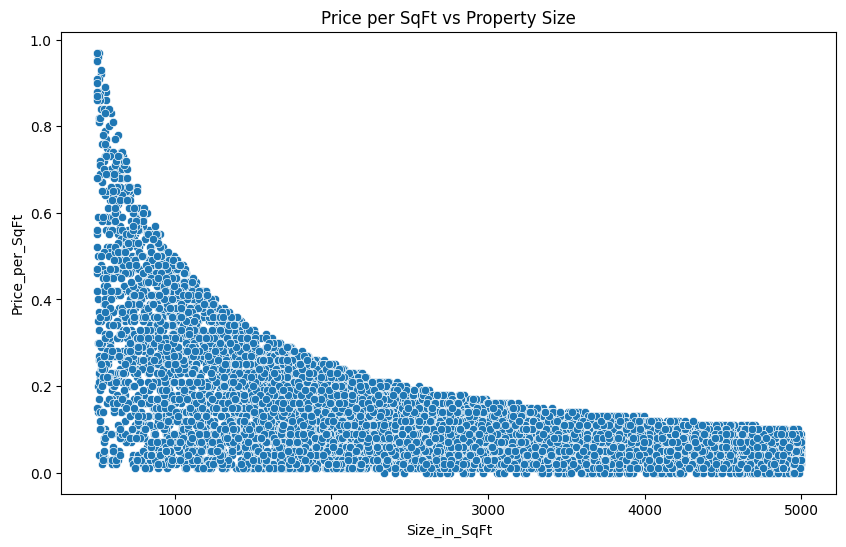

In [72]:
# Price per SqFt vs Size
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Size_in_SqFt', y='Price_per_SqFt', data=df)
plt.title('Price per SqFt vs Property Size')
plt.show()

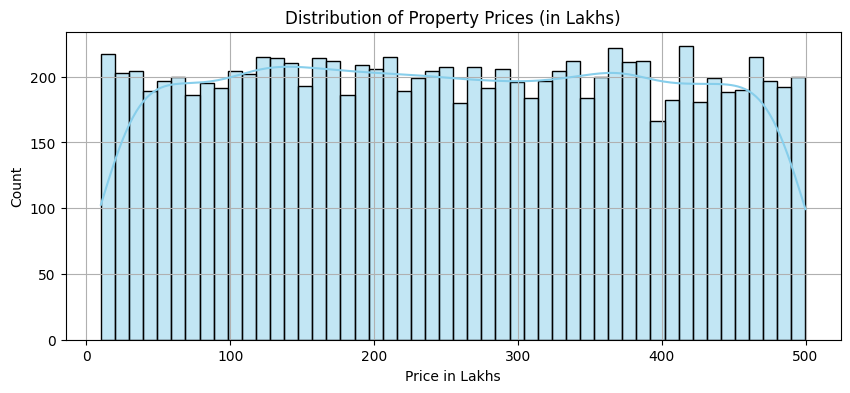

In [73]:
plt.figure(figsize=(10, 4))
sns.histplot(df['Price_in_Lakhs'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Property Prices (in Lakhs)')
plt.xlabel('Price in Lakhs')
plt.ylabel('Count')
plt.grid(True)
plt.show()

In [75]:
len(df['Locality'].unique())

500

# Data Cleaning

In [76]:
# Drop ID
df.drop('ID', axis = 1, inplace=True)

In [77]:
df.drop('Locality', axis = 1, inplace=True)

# Feature Engineering

In [ ]:
mlb = MultiLabelBinarizer()
amenities_encoded = pd.DataFrame(mlb.fit_transform(df['Amenities']), columns=mlb.classes_)

df = pd.concat([df.drop(columns=['Amenities']), amenities_encoded], axis=1)

In [ ]:
# Define column groups
ordinal_cols = ['Property_Type', 'Public_Transport_Accessibility', 'Furnished_Status', 'Facing', 'Availability_Status', 'Security', 'Parking_Space' ]
categories = [['Apartment', 'Independent House', 'Villa'], ['Low', 'Medium', 'High'], ['Unfurnished', 'Semi-furnished', 'Furnished'], ['North', 'West', 'East', 'South'],  # as priorities in India
              ['Under_Construction', 'Ready_to_Move'], ['No', 'Yes'], ['No', 'Yes']]
encoder = OrdinalEncoder(categories=categories)
df[ordinal_cols] = encoder.fit_transform(df[ordinal_cols])

In [ ]:
df.head()

,State,City,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,...,Clubhouse,Garden,Gym,Playground,Pool,Clubhouse,Garden,Gym,Playground,Pool
0,Haryana,Gurgaon,1.0,4,692,256.62,0.37,2022,1.0,15,...,0,0,0,0,1,0,0,0,1,0
1,Andhra Pradesh,Vishakhapatnam,0.0,2,3094,86.04,0.03,2015,2.0,3,...,1,1,0,0,1,0,0,1,0,0
2,Madhya Pradesh,Bhopal,0.0,3,4993,237.86,0.05,1995,0.0,19,...,1,1,0,1,1,0,0,1,0,0
3,Punjab,Ludhiana,2.0,1,2461,339.41,0.14,2018,1.0,20,...,0,0,1,0,0,0,0,0,0,1
4,Haryana,Faridabad,1.0,2,4535,124.99,0.03,1991,1.0,25,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
cat_col = [column for column in df.columns if df[column].dtype == 'object']
num_col = [column for column in df.columns if df[column].dtype != 'object']
len(cat_col), len(num_col)

(3, 27)

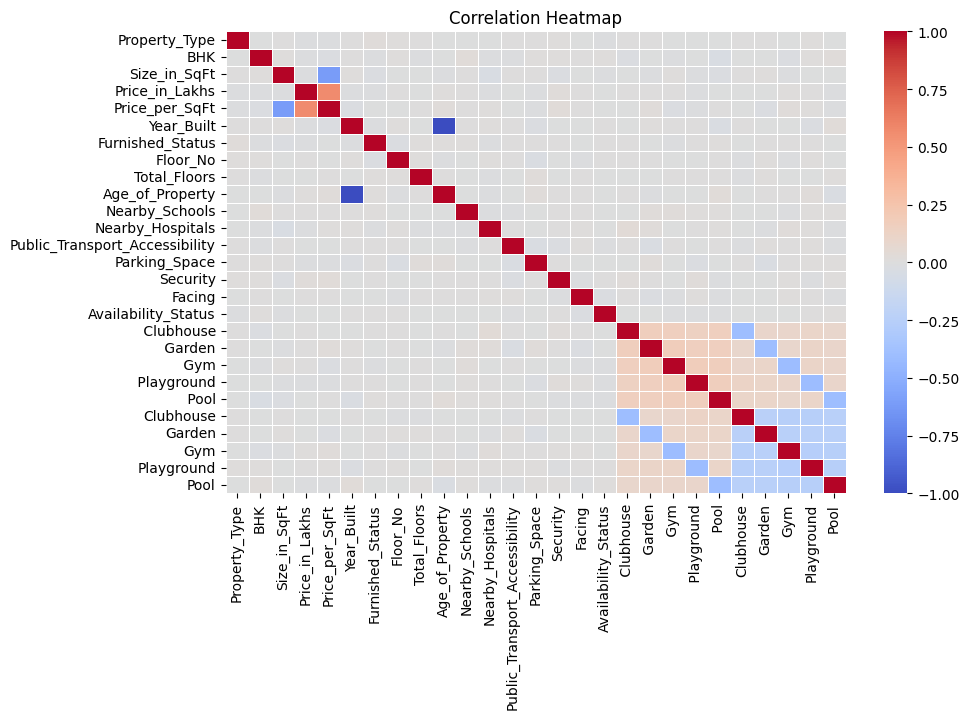

In [ ]:
correlation_matrix = df[num_col].corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# Split Dataset for Training

In [83]:
# Define features and target
X = df.drop(columns=['Price_in_Lakhs'])
y = df['Price_in_Lakhs']

In [84]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

In [85]:
len(X_test), len(X_train)

(2000, 8000)

In [86]:
train_dicts = X_train.to_dict(orient='records')
test_dicts = X_test.to_dict(orient='records')

In [87]:
from sklearn.feature_extraction import DictVectorizer
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)
X_test = dv.transform(test_dicts)

In [88]:
X_train.shape, X_test.shape

((8000, 91), (2000, 91))

# Model Building

In [89]:
model_results = []

def evaluate_model(y, y_pred):
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)

    return mse, rmse, r2

In [90]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_lr = lr.predict(X_test)

In [121]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_rf = rf.predict(X_test)

In [92]:
xgb = XGBRegressor()
xgb.fit(X_train, y_train)
y_xgb = xgb.predict(X_test)

In [93]:
evaluate_model(y_test, y_lr), evaluate_model(y_test, y_rf), evaluate_model(y_test, y_xgb)

((10422.828878995582, np.float64(102.09225670439254), 0.4890529065869541),
 (96.05674688072999, np.float64(9.800854395445837), 0.995291113747408),
 (117.63239248451585, np.float64(10.84584678503785), 0.9942334341541087))

# Hyper-Parameter Tuning

In [94]:
params_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb = XGBRegressor(random_state=42)

grid_xgb = GridSearchCV(xgb, params_xgb, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_xgb.fit(X_train, y_train)
grid_xgb.best_params_

Fitting 5 folds for each of 162 candidates, totalling 810 fits


{'colsample_bytree': 1.0,
 'learning_rate': 0.1,
 'max_depth': 6,
 'n_estimators': 100,
 'subsample': 1.0}

In [95]:
y_xgbh = grid_xgb.predict(X_test)

In [96]:
params_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42)

grid_rf = GridSearchCV(rf, params_rf, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_train)
grid_rf.best_params_

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200]},
             scoring='r2', verbose=1)

In [98]:
y_rfh = grid_rf.predict(X_test)

In [99]:
evaluate_model(y_test, y_xgbh), evaluate_model(y_test, y_rfh)

((97.61246310786007, np.float64(9.879901978656472), 0.9952148495494962),
 (5246.156575698069, np.float64(72.43035672767371), 0.7428233270389277))

# Model Performance on Test Data

In [ ]:
data = pd.read_csv("Housing_Data.csv")
price = pd.read_csv("Price.csv")

In [ ]:
data.drop('ID', axis = 1)
data.drop('Locality', axis = 1)

In [105]:
data = pd.concat([data.drop(columns=['Amenities']), amenities_encoded], axis=1)

In [114]:
data[ordinal_cols] = encoder.fit_transform(data[ordinal_cols])

In [115]:
data_dicts = data.to_dict(orient='records')

In [116]:
X_data = dv.fit_transform(data_dicts)

In [123]:
evaluate_model(price, grid_xgb.predict(X_data)), evaluate_model(price, grid_rf.predict(X_data)), evaluate_model(price, rf.predict(X_data))

((99.06245422363281, np.float64(9.953012319073698), 0.9950140714645386),
 (5191.625989078692, np.float64(72.05293879557372), 0.7386994514933631),
 (99.01629770068402, np.float64(9.950693327637227), 0.9950163950649156))